In [1]:
#| echo: false
#| warning: false
#| output: asis

from IPython.display import Markdown, display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import logit, probit
from statsmodels.iolib.summary2 import summary_params, summary_col
from scipy.stats import norm, logistic, chi2
import warnings
warnings.simplefilter(action='ignore', category=Warning)

# Загрузка данных
loanapp = pd.read_csv('../datasets/loanapp.csv')
mroz_Greene = pd.read_csv('../datasets/TableF5-1.csv')
SwissLabor = pd.read_csv('../datasets/SwissLabor.csv')

# Очистка пропусков для loanapp
loanapp = loanapp[['approve', 'appinc', 'mortno', 'unem', 'dep', 'male', 'married', 'yjob', 'self']].dropna()

# преобразуем данные столбцов participation и foreign для SwissLabor
# SwissLabor['participation'] = SwissLabor['participation'].replace('yes', 1)
# SwissLabor['participation'] = SwissLabor['participation'].replace('no', 0)
# SwissLabor['foreign'] = SwissLabor['foreign'].replace('yes', 1)
# SwissLabor['foreign'] = SwissLabor['foreign'].replace('no', 0)

# Гарантированно переводим в числа (даже если ячейка запустится дважды, ошибки не будет)
SwissLabor['participation'] = SwissLabor['participation'].replace({'yes': 1, 'no': 0}).astype(int)
SwissLabor['foreign'] = SwissLabor['foreign'].replace({'yes': 1, 'no': 0}).astype(int)

# Настройки графиков
plt.rcParams['figure.figsize'] = (8.5, 6)
plt.rcParams['font.size'] = 10

# --- ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ QUARTO ---
def display_answer(text, use_callout=True, theme="note", title="Критическое значение"):
    if use_callout:
        if title:
            output_md = f"\n\n::: {{.callout-{theme} title=\"{title}\" icon=\"true\"}}\n{text}\n:::\n\n"
        else:
            output_md = f"\n\n::: {{.callout-{theme} icon=\"true\"}}\n{text}\n:::\n\n"
    else:
        if title:
            output_md = f"\n\n**{title}:** {text}\n\n"
        else:
            output_md = f"\n\n{text}\n\n"
    display(Markdown(output_md))

def print_coefs(res, digits=3):
    df = pd.DataFrame({'Переменная': res.params.index, 'Оценка (MLE)': np.round(res.params, digits)})
    display(Markdown(df.to_markdown(index=False)))

def get_stars(p_value):
    if p_value < 0.01: return '***'
    elif p_value < 0.05: return '**'
    elif p_value < 0.1: return '*'
    return ''

def print_z_test(res, sign_level=0.05, digits=4):
    df = pd.DataFrame({
        'Coef.': res.params,
        'Std.Err.': res.bse,
        'z-value': res.tvalues,
        'p-value': res.pvalues
    }).round(digits)
    df['Signif.'] = df['p-value'].apply(get_stars)
    for const_name in ['const', 'Intercept']:
        if const_name in df.index:
            df.loc[const_name, 'Signif.'] = ''
    legend = "\n*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$"
    display(Markdown(df.to_markdown(index=True) + "\n" + legend))

# def print_significant_coeffs(res, sign_level=0.05):
#     all_sign_coeffs = res.params.index[res.pvalues < sign_level].tolist()
#     sign_coeffs = [coef for coef in all_sign_coeffs if coef not in ['const', 'Intercept']]
#     percent_level = f"{sign_level * 100:g}"
#     title = f"Коэффициенты, значимые на уровне {percent_level}%"
#     if sign_coeffs:
#         text = ", ".join([f"`{coef}`" for coef in sign_coeffs])
#     else:
#         text = "Значимых коэффициентов не выявлено."
#     display_answer(text, use_callout=True, theme="note", title=title)

def print_significant_coeffs(res, sign_level=0.05, use_callout=False, theme="note", title=None):
    """
    Выводит список статистически значимых коэффициентов регрессии (без константы).
    """
    # 1. Автоматически извлекаем тип стандартных ошибок из модели
    cov_type = getattr(res, 'cov_type', 'nonrobust')
    is_robust = cov_type != 'nonrobust'
    
    if is_robust:
        error_type = f"по робастным стандартным ошибкам {cov_type}"
    else:
        error_type = "по классическим стандартным ошибкам"

    # 2. Отбираем значимые коэффициенты
    all_sign_coeffs = res.params.index[res.pvalues < sign_level].tolist()

    # 3. Исключаем константу
    sign_coeffs = [coef for coef in all_sign_coeffs if coef not in ['const', 'Intercept']]

    # 4. Переводим уровень значимости в проценты
    percent_level = f"{sign_level * 100:g}"

    # --- 5. ФОРМИРУЕМ ЭЛЕМЕНТЫ ВЫВОДА ---
    
    # Базовый динамический заголовок
    dynamic_title = f"Коэффициенты, значимые на уровне {percent_level}% ({error_type})"
    
    # Заголовок, который реально будет использован (динамический, если не передан свой)
    actual_title = title if title is not None else dynamic_title

    # Содержимое (только переменные или короткое сообщение об отсутствии)
    if sign_coeffs:
        formatted_coeffs = ", ".join([f"`{coef}`" for coef in sign_coeffs])
        content_text = formatted_coeffs
    else:
        content_text = "Значимых коэффициентов не выявлено."

    # --- 6. СОБИРАЕМ РЕЗУЛЬТАТ С РАМКОЙ ИЛИ БЕЗ ---
    
    if use_callout:
        # В рамке: подробный текст уходит в заголовок, внутри только список переменных
        output_md = f"\n\n::: {{.callout-{theme} title=\"{actual_title}\" icon=\"true\"}}\n{content_text}\n:::\n\n"
    else:
        # Без рамки: все в одной строке (с жирным префиксом)
        output_md = f"\n\n**{actual_title}:**\n\n {content_text}\n\n"

    display(Markdown(output_md))


# Нормальное и логистическое распределения

**Стандартное нормальное (гауссово) распределение $N(0, 1)$**

* Плотность вероятности:
$$\phi(t) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{t^2}{2}\right), \quad t \in \mathbb{R}$$

* (Кумулятивная) функция распределения:
$$\Phi(x) = \int\limits_{-\infty}^x \phi(t) \, dt, \quad x \in \mathbb{R}$$

---

**Логистическое распределение**

* (Кумулятивная) функция распределения:
$$\Lambda(x) = \frac{\exp(x)}{1 + \exp(x)}, \quad x \in \mathbb{R}$$

* Плотность вероятности:
$$\lambda(x) = \Lambda'(x) = \frac{\exp(x)}{(1 + \exp(x))^2}, \quad x \in \mathbb{R}$$

---

Плотности на одном графике

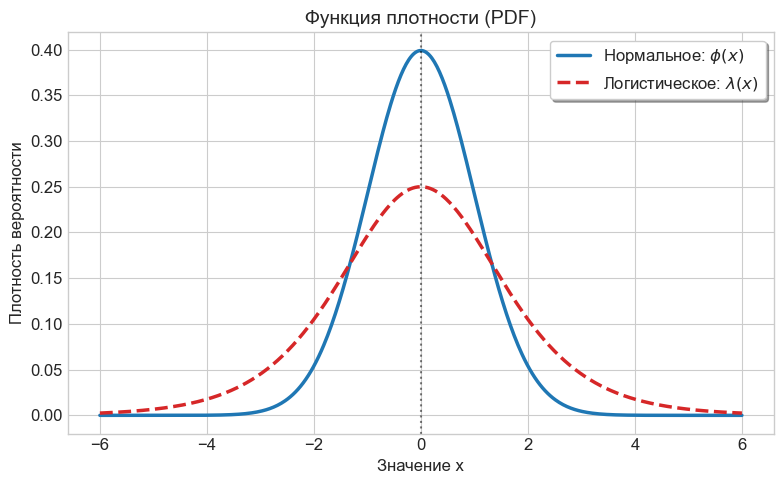

In [2]:
#| echo: false
#| warning: false

# Настройка приятного стиля по умолчанию
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# Общие параметры
x = np.linspace(-6, 6, 500)
p = np.linspace(0.001, 0.999, 500) # Избегаем 0 и 1 для PPF
color_norm = '#1f77b4' # Синий
color_log = '#d62728'  # Красный

# ==========================================
# 1. Функция плотности (PDF)
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(x, norm.pdf(x), color=color_norm, lw=2.5, label=r'Нормальное: $\phi(x)$')
plt.plot(x, logistic.pdf(x), color=color_log, lw=2.5, linestyle='--', label=r'Логистическое: $\lambda(x)$')

plt.axvline(0, color='black', linestyle=':', alpha=0.5)
plt.title('Функция плотности (PDF)')
plt.ylabel('Плотность вероятности')
plt.xlabel('Значение x')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

Функции распределения на одном графике

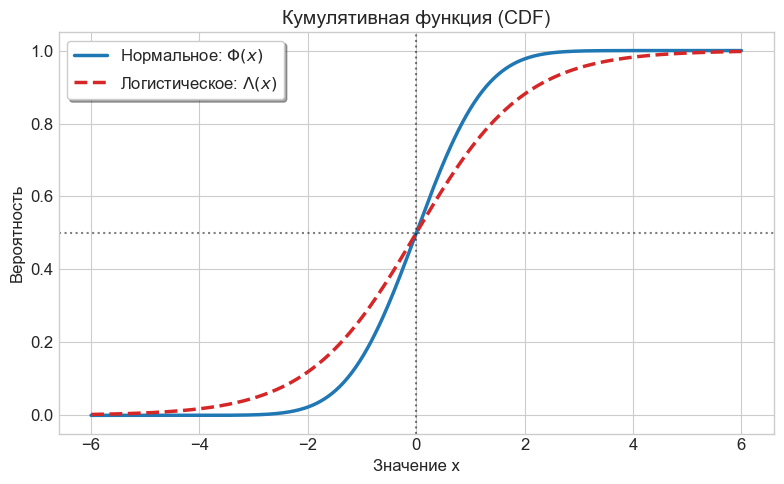

In [3]:
#| echo: false
#| warning: false


# Настройка приятного стиля по умолчанию
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# Общие параметры
x = np.linspace(-6, 6, 500)
p = np.linspace(0.001, 0.999, 500) # Избегаем 0 и 1 для PPF
color_norm = '#1f77b4' # Синий
color_log = '#d62728'  # Красный

# ==========================================
# 2. Кумулятивная функция (CDF)
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(x, norm.cdf(x), color=color_norm, lw=2.5, label=r'Нормальное: $\Phi(x)$')
plt.plot(x, logistic.cdf(x), color=color_log, lw=2.5, linestyle='--', label=r'Логистическое: $\Lambda(x)$')

plt.axvline(0, color='black', linestyle=':', alpha=0.5)
plt.axhline(0.5, color='black', linestyle=':', alpha=0.5) # Полезная линия для медианы
plt.title('Кумулятивная функция (CDF)')
plt.ylabel('Вероятность')
plt.xlabel('Значение x')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

Обратные функции распределения 

$$
logit(p)=\Lambda^{-1}(p)=\log\frac{p}{1-p} \quad \text{ и } \quad probit(p)=\Phi^{-1}(p), \quad 0<p<1
$$

Их графики

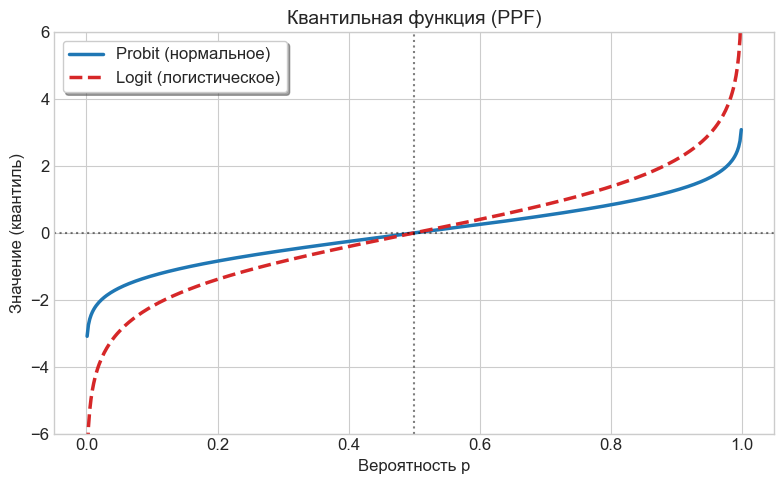

In [4]:
#| echo: false
#| warning: false


# Настройка приятного стиля по умолчанию
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14})

# Общие параметры
x = np.linspace(-6, 6, 500)
p = np.linspace(0.001, 0.999, 500) # Избегаем 0 и 1 для PPF
color_norm = '#1f77b4' # Синий
color_log = '#d62728'  # Красный

# ==========================================
# 3. Квантильная функция (PPF)
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(p, norm.ppf(p), color=color_norm, lw=2.5, label='Probit (нормальное)')
plt.plot(p, logistic.ppf(p), color=color_log, lw=2.5, linestyle='--', label='Logit (логистическое)')

plt.axhline(0, color='black', linestyle=':', alpha=0.5)
plt.axvline(0.5, color='black', linestyle=':', alpha=0.5)
plt.ylim(-6, 6)
plt.title('Квантильная функция (PPF)')
plt.ylabel('Значение (квантиль)')
plt.xlabel('Вероятность p')
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()

In [5]:
# #| echo: false
# #| warning: false

# # 1. Настройка приятного стиля по умолчанию
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13})

# x = np.linspace(-6, 6, 500)
# # Для PPF лучше избегать точных 0 и 1, чтобы не получить бесконечность на краях графика
# p = np.linspace(0.001, 0.999, 500) 

# # 2. Создаем одну фигуру с 3 графиками в ряд (1 строка, 3 колонки)
# fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# # Определяем базовые цвета для единообразия
# color_norm = '#1f77b4' # Глубокий синий
# color_log = '#d62728'  # Приглушенный красный

# # --- График 1: Функция плотности (PDF) ---
# axes[0].plot(x, norm.pdf(x), color=color_norm, lw=2.5, label=r'Нормальное: $\phi(x)$')
# axes[0].plot(x, logistic.pdf(x), color=color_log, lw=2.5, linestyle='--', label=r'Логистическое: $\lambda(x)$')
# axes[0].set_title('Функция плотности (PDF)')
# axes[0].set_xlabel('$x$')
# axes[0].set_ylabel('Плотность')

# # --- График 2: Кумулятивная функция (CDF) ---
# axes[1].plot(x, norm.cdf(x), color=color_norm, lw=2.5, label=r'Нормальное: $\Phi(x)$')
# axes[1].plot(x, logistic.cdf(x), color=color_log, lw=2.5, linestyle='--', label=r'Логистическое: $\Lambda(x)$')
# axes[1].set_title('Кумулятивная функция (CDF)')
# axes[1].set_xlabel('$x$')
# axes[1].set_ylabel('Вероятность')

# # --- График 3: Квантильная функция (PPF) ---
# axes[2].plot(p, norm.ppf(p), color=color_norm, lw=2.5, label='Probit')
# axes[2].plot(p, logistic.ppf(p), color=color_log, lw=2.5, linestyle='--', label='Logit')
# axes[2].set_title('Квантильная функция (PPF)')
# axes[2].set_xlabel('Вероятность $p$')
# axes[2].set_ylabel('Значение ($x$)')
# axes[2].set_ylim(-6, 6)

# # --- Общие настройки для всех графиков в цикле ---
# for ax in axes:
#     # Отрисовка осей, проходящих через ноль
#     ax.axhline(0, color='black', linewidth=1, alpha=0.3)
#     ax.axvline(0, color='black', linewidth=1, alpha=0.3)
#     # Настройка легенды
#     ax.legend(frameon=True, shadow=True, loc='best')

# # Автоматически выравнивает отступы между графиками, чтобы ничего не наезжало
# plt.tight_layout()
# plt.show()

# Оценивание и интерпретация коэффициентов

## approve equation #1 (probit)

Для датасета `loanapp` рассмотрим probit-регрессию __approve на appinc, mortno, unem, dep, male, married, yjob, self__

Спецификация: 

$$
P(approve=1)=\Phi(\beta_0+\beta_1appinc+\beta_2mortno+\beta_3unem+\beta_4dep+\beta_5male+\beta_6married+\beta_7yjob+\beta_8self)
$$

Альтернативная спецификация:

$$
probit(P(approve=1))=\beta_0+\beta_1appinc+\beta_2mortno+\beta_3unem+\beta_4dep+\beta_5male+\beta_6married+\beta_7yjob+\beta_8self
$$


Оцените модель на данных и укажите коэффициенты подогнанной модели. **Ответ округлите до 3-х десятичных знаков.**

Ответ:

In [6]:
#| echo: false
#| warning: false
#| output: asis

formula_app = 'approve ~ appinc + mortno + unem + dep + male + married + yjob + self'
mod_probit_app = probit(formula_app, data=loanapp).fit(disp=0)
print_coefs(mod_probit_app, digits=3)

| Переменная   |   Оценка (MLE) |
|:-------------|---------------:|
| Intercept    |          1.142 |
| appinc       |         -0.001 |
| mortno       |          0.407 |
| unem         |         -0.031 |
| dep          |         -0.083 |
| male         |          0.02  |
| married      |          0.221 |
| yjob         |         -0.001 |
| self         |         -0.158 |

Дайте интерпретацию коэффициентам модели.

## approve equation #2 (logit)

Для датасета `loanapp` рассмотрим logit-регрессию __approve на appinc, mortno, unem, dep, male, married, yjob, self__

Спецификация: 

$$
P(approve=1)=\Lambda(\beta_0+\beta_1appinc+\beta_2mortno+\beta_3unem+\beta_4dep+\beta_5male+\beta_6married+\beta_7yjob+\beta_8self)
$$

Альтернативная спецификация:

$$
logit(P(approve=1))=\beta_0+\beta_1appinc+\beta_2mortno+\beta_3unem+\beta_4dep+\beta_5male+\beta_6married+\beta_7yjob+\beta_8self
$$

Здесь 

$$
logit(P(approve=1)) = \log\frac{P(approve=1)}{1-P(approve=1)} = \log\frac{P(approve=1)}{P(approve=0)}
$$

Оцените модель на данных и укажите коэффициенты подогнанной модели. **Ответ округлите до 3-х десятичных знаков.**

Ответ:

In [7]:
#| echo: false
#| warning: false
#| output: asis

mod_logit_app = logit(formula_app, data=loanapp).fit(disp=0)
print_coefs(mod_logit_app, digits=3)

| Переменная   |   Оценка (MLE) |
|:-------------|---------------:|
| Intercept    |          1.931 |
| appinc       |         -0.001 |
| mortno       |          0.787 |
| unem         |         -0.055 |
| dep          |         -0.161 |
| male         |          0.03  |
| married      |          0.425 |
| yjob         |         -0.006 |
| self         |         -0.28  |

Дайте интерпретацию коэффициентам модели.

## labour force equation #1 (probit)

Для датасета `TableF5-1` рассмотрим probit-регрессию __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__

Спецификация: 

$$
P(LFP=1)=\Phi(\beta_0+\beta_1WA+\beta_2WA^2+\beta_3WE+\beta_4KL6+\beta_5K618+\beta_6CIT+\beta_7UN+\beta_8\log(FAMINC))
$$

Альтернативная спецификация:

$$
probit(P(LFP=1))=\beta_0+\beta_1WA+\beta_2WA^2+\beta_3WE+\beta_4KL6+\beta_5K618+\beta_6CIT+\beta_7UN+\beta_8\log(FAMINC)
$$



Оцените модель на данных и укажите коэффициенты подогнанной модели. **Ответ округлите до 3-х десятичных знаков.**

Ответ:

In [8]:
#| echo: false
#| warning: false
#| output: asis

formula_lfp = 'LFP ~ WA + I(WA**2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)'
mod_probit_lfp = probit(formula_lfp, data=mroz_Greene).fit(disp=0)
print_coefs(mod_probit_lfp, digits=3)

| Переменная     |   Оценка (MLE) |
|:---------------|---------------:|
| Intercept      |         -2.005 |
| WA             |          0.008 |
| I(WA ** 2)     |         -0.001 |
| WE             |          0.109 |
| KL6            |         -0.851 |
| K618           |         -0.063 |
| CIT            |         -0.128 |
| UN             |         -0.011 |
| np.log(FAMINC) |          0.2   |

Дайте интерпретацию коэффициентам модели.

## labour force equation #2 (logit)

Для датасета `TableF5-1` рассмотрим logit-регрессию __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__

Спецификация: 

$$
P(LFP=1)=\Lambda(\beta_0+\beta_1WA+\beta_2WA^2+\beta_3WE+\beta_4KL6+\beta_5K618+\beta_6CIT+\beta_7UN+\beta_8\log(FAMINC))
$$

Альтернативная спецификация:

$$
logit(LFP)=\beta_0+\beta_1WA+\beta_2WA^2+\beta_3WE+\beta_4KL6+\beta_5K618+\beta_6CIT+\beta_7UN+\beta_8\log(FAMINC)
$$

Здесь 

$$
logit(P(LFP=1)) = \log\frac{P(LFP=1)}{1-P(LFP=1)} = \log\frac{P(LFP=1)}{P(LFP=0)}
$$

Оцените модель на данных и укажите коэффициенты подогнанной модели. **Ответ округлите до 3-х десятичных знаков.**

Ответ:

In [9]:
#| echo: false
#| warning: false
#| output: asis

mod_logit_lfp = logit(formula_lfp, data=mroz_Greene).fit(disp=0)
print_coefs(mod_logit_lfp, digits=3)

| Переменная     |   Оценка (MLE) |
|:---------------|---------------:|
| Intercept      |         -3.241 |
| WA             |          0.007 |
| I(WA ** 2)     |         -0.001 |
| WE             |          0.18  |
| KL6            |         -1.414 |
| K618           |         -0.104 |
| CIT            |         -0.217 |
| UN             |         -0.018 |
| np.log(FAMINC) |          0.333 |

Дайте интерпретацию коэффициентам модели.

# z-test

## approve equation #1 (probit)

Для датасета `loanapp` рассмотрим probit-регрессию __approve на appinc, mortno, unem, dep, male, married, yjob, self__

Подгоните модель на данных и приведите результаты $z$-теста

Ответ:

In [10]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
print_z_test(mod_probit_app, sign_level=sign_level, digits=4)

text_info = f"Модель была подогнана по {int(mod_probit_app.nobs)} наблюдениям. <span style='color: blue'>Уровень значимости {int(sign_level*100)}%</span>"
display(Markdown(f"\n\n{text_info}\n\n"))

|           |   Coef. |   Std.Err. |   z-value |   p-value | Signif.   |
|:----------|--------:|-----------:|----------:|----------:|:----------|
| Intercept |  1.1418 |     0.1086 |   10.5122 |    0      |           |
| appinc    | -0.0005 |     0.0004 |   -1.3752 |    0.1691 |           |
| mortno    |  0.4071 |     0.0866 |    4.7026 |    0      | ***       |
| unem      | -0.0308 |     0.0161 |   -1.9086 |    0.0563 | *         |
| dep       | -0.0828 |     0.0352 |   -2.3546 |    0.0185 | **        |
| male      |  0.02   |     0.0995 |    0.2009 |    0.8408 |           |
| married   |  0.2208 |     0.0865 |    2.5522 |    0.0107 | **        |
| yjob      | -0.0007 |     0.0349 |   -0.02   |    0.984  |           |
| self      | -0.1583 |     0.1067 |   -1.4826 |    0.1382 |           |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$



Модель была подогнана по 1971 наблюдениям. <span style='color: blue'>Уровень значимости 10%</span>



Вычислите необходимое критическое значение $z$-теста. **Ответ округлите до 3-х десятичных знаков.**

In [11]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
z_cr = norm.isf(sign_level/2)  # Критическое значение для двустороннего теста
display_answer(f"$z_{{crit}} = {z_cr:.3f}$", title="Критическое значение z-теста")



::: {.callout-note title="Критическое значение z-теста" icon="true"}
$z_{crit} = 1.645$
:::



Какие коэффициенты значимы?

In [12]:
#| echo: false
#| warning: false
#| output: asis

print_significant_coeffs(mod_probit_app, sign_level=sign_level, use_callout=True)



::: {.callout-note title="Коэффициенты, значимые на уровне 10% (по классическим стандартным ошибкам)" icon="true"}
`mortno`, `unem`, `dep`, `married`
:::



## approve equation #2 (logit)

Для датасета `loanapp` рассмотрим logit-регрессию __approve на appinc, mortno, unem, dep, male, married, yjob, self__

Подгоните модель на данных и приведите результаты $z$-теста

Ответ:

In [13]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
print_z_test(mod_logit_app, sign_level=sign_level, digits=4)

text_info = f"Модель была подогнана по {int(mod_logit_app.nobs)} наблюдениям. <span style='color: blue'>Уровень значимости {int(sign_level*100)}%</span>"
display(Markdown(f"\n\n{text_info}\n\n"))

|           |   Coef. |   Std.Err. |   z-value |   p-value | Signif.   |
|:----------|--------:|-----------:|----------:|----------:|:----------|
| Intercept |  1.9315 |     0.1993 |    9.6891 |    0      |           |
| appinc    | -0.001  |     0.0007 |   -1.4717 |    0.1411 |           |
| mortno    |  0.7868 |     0.1721 |    4.5714 |    0      | ***       |
| unem      | -0.0549 |     0.0294 |   -1.8661 |    0.062  | *         |
| dep       | -0.1608 |     0.0647 |   -2.4861 |    0.0129 | **        |
| male      |  0.03   |     0.1859 |    0.1612 |    0.8719 |           |
| married   |  0.4246 |     0.1624 |    2.6145 |    0.0089 | ***       |
| yjob      | -0.0065 |     0.0651 |   -0.0993 |    0.9209 |           |
| self      | -0.2804 |     0.1967 |   -1.4257 |    0.1539 |           |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$



Модель была подогнана по 1971 наблюдениям. <span style='color: blue'>Уровень значимости 5%</span>



Вычислите необходимое критическое значение $z$-теста. **Ответ округлите до 3-х десятичных знаков.**

In [14]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
z_cr = norm.isf(sign_level/2)  # Критическое значение для двустороннего теста

display_answer(f"$z_{{crit}} = {z_cr:.3f}$", title="Критическое значение z-теста")



::: {.callout-note title="Критическое значение z-теста" icon="true"}
$z_{crit} = 1.960$
:::



Какие коэффициенты значимы?

In [15]:
#| echo: false
#| warning: false
#| output: asis

print_significant_coeffs(mod_logit_app, sign_level=sign_level, use_callout=True)



::: {.callout-note title="Коэффициенты, значимые на уровне 5% (по классическим стандартным ошибкам)" icon="true"}
`mortno`, `dep`, `married`
:::



## labour force equation #1 (probit)

Для датасета `TableF5-1` рассмотрим probit-регрессию __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__

Подгоните модель на данных и приведите результаты z-теста

Ответ:

In [16]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
print_z_test(mod_probit_lfp, sign_level=sign_level, digits=4)

text_info = f"Модель была подогнана по {int(mod_probit_lfp.nobs)} наблюдениям. <span style='color: blue'>Уровень значимости {int(sign_level*100)}%</span>"
display(Markdown(f"\n\n{text_info}\n\n"))

|                |   Coef. |   Std.Err. |   z-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      | -2.0046 |     1.7055 |   -1.1754 |    0.2398 |           |
| WA             |  0.0076 |     0.0703 |    0.1084 |    0.9137 |           |
| I(WA ** 2)     | -0.0005 |     0.0008 |   -0.6538 |    0.5132 |           |
| WE             |  0.1088 |     0.0241 |    4.514  |    0      | ***       |
| KL6            | -0.8513 |     0.1146 |   -7.4277 |    0      | ***       |
| K618           | -0.0632 |     0.0415 |   -1.5206 |    0.1284 |           |
| CIT            | -0.1277 |     0.1074 |   -1.1891 |    0.2344 |           |
| UN             | -0.0106 |     0.0157 |   -0.6785 |    0.4975 |           |
| np.log(FAMINC) |  0.1996 |     0.1046 |    1.9081 |    0.0564 | *         |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$



Модель была подогнана по 753 наблюдениям. <span style='color: blue'>Уровень значимости 10%</span>



Вычислите необходимое критическое значение $z$-теста. **Ответ округлите до 3-х десятичных знаков.**

In [17]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
z_cr = norm.isf(sign_level/2)  # Критическое значение для двустороннего теста
display_answer(f"$z_{{crit}} = {z_cr:.3f}$", title="Критическое значение z-теста")



::: {.callout-note title="Критическое значение z-теста" icon="true"}
$z_{crit} = 1.645$
:::



Какие коэффициенты значимы?

In [18]:
#| echo: false
#| warning: false
#| output: asis

print_significant_coeffs(mod_probit_lfp, sign_level=sign_level, use_callout=True)



::: {.callout-note title="Коэффициенты, значимые на уровне 10% (по классическим стандартным ошибкам)" icon="true"}
`WE`, `KL6`, `np.log(FAMINC)`
:::



## labour force equation #2 (logit)

Для датасета `TableF5-1` рассмотрим logit-регрессию __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__

Подгоните модель на данных и приведите результаты $z$-теста

Ответ:

In [19]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
print_z_test(mod_logit_lfp, sign_level=sign_level, digits=4)

text_info = f"Модель была подогнана по {int(mod_logit_lfp.nobs)} наблюдениям. <span style='color: blue'>Уровень значимости {int(sign_level*100)}%</span>"
display(Markdown(f"\n\n{text_info}\n\n"))

|                |   Coef. |   Std.Err. |   z-value |   p-value | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|:----------|
| Intercept      | -3.2407 |     2.8337 |   -1.1436 |    0.2528 |           |
| WA             |  0.007  |     0.1159 |    0.0602 |    0.952  |           |
| I(WA ** 2)     | -0.0008 |     0.0013 |   -0.6061 |    0.5444 |           |
| WE             |  0.18   |     0.0404 |    4.4535 |    0      | ***       |
| KL6            | -1.4138 |     0.1987 |   -7.1152 |    0      | ***       |
| K618           | -0.1042 |     0.0687 |   -1.5166 |    0.1294 |           |
| CIT            | -0.2165 |     0.1765 |   -1.2267 |    0.2199 |           |
| UN             | -0.0176 |     0.0258 |   -0.6812 |    0.4957 |           |
| np.log(FAMINC) |  0.3331 |     0.1729 |    1.9272 |    0.054  | *         |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$



Модель была подогнана по 753 наблюдениям. <span style='color: blue'>Уровень значимости 5%</span>



Вычислите необходимое критическое значение $z$-теста. **Ответ округлите до 3-х десятичных знаков.**

In [20]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
z_cr = norm.isf(sign_level/2)  # Критическое значение для двустороннего теста
display_answer(f"$z_{{crit}} = {z_cr:.3f}$", title="Критическое значение z-теста")



::: {.callout-note title="Критическое значение z-теста" icon="true"}
$z_{crit} = 1.960$
:::



Какие коэффициенты значимы?

In [21]:
#| echo: false
#| warning: false
#| output: asis

print_significant_coeffs(mod_logit_lfp, sign_level=sign_level, use_callout=True)



::: {.callout-note title="Коэффициенты, значимые на уровне 5% (по классическим стандартным ошибкам)" icon="true"}
`WE`, `KL6`
:::



# LR-тест: значимость регрессии

## approve equation #1 (probit)

Для датасета `loanapp` рассмотрим probit-регрессию __approve на appinc, unem, male, yjob, self__

Подгоните модель на данных и укажите: 

- число наблюдений, на которых была подогнана модель
- логарифм функции правдоподобия для модели $\log L$
- логарифм функции правдоподобия для регрессии без объясняющих переменных (только на константу)

**Ответ округлите до 4-х десятичных знаков**.

In [22]:
#| echo: false
#| warning: false
#| output: asis

# Строим probit-модель
mod_probit_approve = probit('approve ~ appinc + unem + male + yjob + self', data=loanapp).fit(disp=0)

text = f"""
**Ответ:**

- число наблюдений: {int(mod_probit_approve.nobs)}
- логарифм функции правдоподобия: $\log L = {mod_probit_approve.llf:.4f}$
- логарифм функции правдоподобия для регрессии на константу: $\log L_{{null}} = {mod_probit_approve.llnull:.4f}$
"""

display(Markdown(text))


**Ответ:**

- число наблюдений: 1971
- логарифм функции правдоподобия: $\log L = -733.7270$
- логарифм функции правдоподобия для регрессии на константу: $\log L_{null} = -737.9793$


Тестируется значимость регрессии, т.е. гипотеза $H_0:\beta_{appinc}=\beta_{unem}=\beta_{male}=\beta_{yjob}=\beta_{self}=0$.
<span style="color: blue">Уровень значимости 10%.</span>

Вычислите тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [23]:
#| echo: false
#| warning: false
#| output: asis

lr_stat = mod_probit_approve.llr
display_answer(f"$LR = {lr_stat:.3f}$", title="LR Статистика")



::: {.callout-note title="LR Статистика" icon="true"}
$LR = 8.505$
:::



Вычислите критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [24]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
chi2_cr = chi2.isf(sign_level, df=mod_probit_approve.df_model)
display_answer(f"$\chi^2_{{crit}} = {chi2_cr:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 9.236$
:::



Значима ли регрессия?

In [25]:
#| echo: false
#| warning: false
#| output: asis

if lr_stat > chi2_cr:
    display_answer("Регрессия **значима**.", theme="tip", title="Вывод")
else:
    display_answer("Регрессия **незначима**.", theme="important", title="Вывод")



::: {.callout-important title="Вывод" icon="true"}
Регрессия **незначима**.
:::



Какие коэффициенты значимы?

In [26]:
#| echo: false
#| warning: false
#| output: asis

print_significant_coeffs(mod_probit_approve, sign_level=sign_level, use_callout=True)



::: {.callout-note title="Коэффициенты, значимые на уровне 10% (по классическим стандартным ошибкам)" icon="true"}
`unem`
:::



## approve equation #2 (logit)

Для датасета `loanapp` рассмотрим logit-регрессию __approve на appinc, appinc ** 2, mortno, unem, dep, male, married, yjob, self__

Подгоните модель на данных и укажите: 

- число наблюдений, на которых была подогнана модель
- логарифм функции правдоподобия для модели $\log L$
- логарифм функции правдоподобия для регрессии без объясняющих переменных (только на константу)

**Ответ округлите до 4-х десятичных знаков.**

In [27]:
#| echo: false
#| warning: false
#| output: asis

# Строим logit-модель
mod_logit_approve = logit('approve ~ appinc + I(appinc**2) + mortno + unem + dep + male + married + yjob + self', data=loanapp).fit(disp=0)

text = f"""
**Ответ:**

- число наблюдений: {int(mod_logit_approve.nobs)}
- логарифм функции правдоподобия: $\log L = {mod_logit_approve.llf:.4f}$
- логарифм функции правдоподобия для регрессии на константу: $\log L_{{null}} = {mod_logit_approve.llnull:.4f}$
"""

display(Markdown(text))


**Ответ:**

- число наблюдений: 1971
- логарифм функции правдоподобия: $\log L = -713.7313$
- логарифм функции правдоподобия для регрессии на константу: $\log L_{null} = -737.9793$


Тестируется значимость регрессии, т.е. гипотеза
$H_0:\beta_{appinc}=\beta_{unem}=\beta_{male}=\beta_{yjob}=\beta_{self}=0$.
<span style="color: blue">Уровень значимости 5%</span>.

Вычислите тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [28]:
#| echo: false
#| warning: false
#| output: asis

# LR-статистика
lr_stat = mod_logit_approve.llr

display_answer(f"$LR = {lr_stat:.3f}$", title="LR-статистика")



::: {.callout-note title="LR-статистика" icon="true"}
$LR = 48.496$
:::



Вычислите критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [29]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
# Степени свободы = количеству предикторов
chi2_cr = chi2.isf(sign_level, df=mod_logit_approve.df_model)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 16.919$
:::



Значима ли регрессия?

In [30]:
#| echo: false
#| warning: false
#| output: asis

if lr_stat > chi2_cr:
    display_answer("Регрессия **значима**.", theme="tip", title="Вывод")
else:
    display_answer("Регрессия **незначима**.", theme="important", title="Вывод")



::: {.callout-tip title="Вывод" icon="true"}
Регрессия **значима**.
:::



Какие коэффициенты значимы?

In [31]:
#| echo: false
#| warning: false
#| output: asis

print_significant_coeffs(mod_logit_approve, sign_level=sign_level, use_callout=True)



::: {.callout-note title="Коэффициенты, значимые на уровне 5% (по классическим стандартным ошибкам)" icon="true"}
`I(appinc ** 2)`, `mortno`, `dep`, `married`
:::



## labour force equation #1 (probit)

Для датасета `TableF5-1` рассмотрим несколько probit-регрессий:

- Модель 1: __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__
- Модель 2: __LFP на WA, I(WA ** 2), CIT, UN, np.log(FAMINC)__ 
- Модель 3: __LFP на WA, I(WA ** 2), CIT, UN__
- Модель 4: __LFP на CIT, UN__ 

Результаты оценивания:

In [32]:
#| echo: false
#| warning: false
#| output: asis

my_digits = 3
my_digits_output = 4
sign_level = 0.10

# Определяем формулы (зависимая переменная LFP)
f1 = 'LFP ~ 1 + WA + I(WA**2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)'
# убираем WE, KL6, K618
f2 = 'LFP ~ 1 + WA + I(WA**2) + CIT + UN + np.log(FAMINC)'
# Убираем log(FAMINC)
f3 = 'LFP ~ 1 + WA + I(WA**2) + CIT + UN'
# Убираем WA и WA^2
f4 = 'LFP ~ 1 + CIT + UN'

# Оцениваем probit-модели для каждой формулы
probit_lfp_models = [
    probit(f1, data=mroz_Greene).fit(disp=0),
    probit(f2, data=mroz_Greene).fit(disp=0),
    probit(f3, data=mroz_Greene).fit(disp=0),
    probit(f4, data=mroz_Greene).fit(disp=0)
]

model_titles = ['Model 1', 'Model 2', 'Model 3', 'Model 4']

# Собираем базовую таблицу
compare_table = summary_col(
    probit_lfp_models, 
    model_names=model_titles,
    stars=True, 
    regressor_order=[
        'WA', 'I(WA ** 2)', 'WE', 'KL6', 'K618', 
        'CIT', 'UN', 'np.log(FAMINC)', 'Intercept'
    ],
    float_format=f'%0.{my_digits_output}f',
    info_dict={
        'Nobs': lambda x: f"{int(x.nobs)}",
        'Log-Likelihood': lambda x: f"{x.llf:.{my_digits}f}"
    }
)

df_compare = compare_table.tables[0]

# Добавляем строку с зависимой переменной наверх (как вы делали в list21)
dep_vars_dict = {
    col_name: [model.model.endog_names] 
    for col_name, model in zip(df_compare.columns, probit_lfp_models)
}
top_row = pd.DataFrame(dep_vars_dict, index=['Dep. Variable'])
df_compare = pd.concat([top_row, df_compare])

# Формируем безопасную для XeLaTeX легенду
legend_text = "\n\n*Signif. codes:* \\*\\*\\* $p<0.01$, \\*\\* $p<0.05$, \\* $p<0.1$"

display(Markdown(df_compare.to_markdown() + legend_text))

|                | Model 1    | Model 2    | Model 3   | Model 4   |
|:---------------|:-----------|:-----------|:----------|:----------|
| Dep. Variable  | LFP        | LFP        | LFP       | LFP       |
| WA             | 0.0076     | 0.1084*    | 0.1297**  |           |
|                | (0.0703)   | (0.0632)   | (0.0629)  |           |
| I(WA ** 2)     | -0.0005    | -0.0014*   | -0.0016** |           |
|                | (0.0008)   | (0.0007)   | (0.0007)  |           |
| WE             | 0.1088***  |            |           |           |
|                | (0.0241)   |            |           |           |
| KL6            | -0.8513*** |            |           |           |
|                | (0.1146)   |            |           |           |
| K618           | -0.0632    |            |           |           |
|                | (0.0415)   |            |           |           |
| CIT            | -0.1277    | -0.1026    | 0.0053    | -0.0024   |
|                | (0.1074)   | (0.1030)   | (0.0984)  | (0.0975)  |
| UN             | -0.0106    | -0.0101    | -0.0102   | -0.0115   |
|                | (0.0157)   | (0.0151)   | (0.0151)  | (0.0150)  |
| np.log(FAMINC) | 0.1996*    | 0.3621***  |           |           |
|                | (0.1046)   | (0.0946)   |           |           |
| Intercept      | -2.0046    | -5.2366*** | -2.1745   | 0.2733*   |
|                | (1.7055)   | (1.5554)   | (1.3261)  | (0.1407)  |
| Log-Likelihood | -462.340   | -502.224   | -509.653  | -514.563  |
| Nobs           | 753        | 753        | 753       | 753       |

*Signif. codes:* \*\*\* $p<0.01$, \*\* $p<0.05$, \* $p<0.1$

Для каждой регрессии вычислите LR-статистику для тестирования её значимости.
**Ответ округлите до 3-х десятичных знаков.**

In [33]:
#| echo: false
#| warning: false
#| output: asis

lr_stats_lfp = []
for m in probit_lfp_models:
    lr_stats_lfp.append(m.llr)

df_lr_lfp = pd.DataFrame({
    'Регрессия': range(1, len(probit_lfp_models) + 1), 
    'LR-статистика': np.round(lr_stats_lfp, my_digits) # Округляем до my_digits знаков 'LR stat'
})

display(Markdown(df_lr_lfp.to_markdown(index=False)))

|   Регрессия |   LR-статистика |
|------------:|----------------:|
|           1 |         105.066 |
|           2 |          25.299 |
|           3 |          10.44  |
|           4 |           0.62  |

Для каждой регрессии вычислите необходимое критическое значение. 
<span style="color: blue">Уровень значимости 10%</span>.
**Ответ округлите до 3-х десятичных знаков.**

In [34]:
#| echo: false
#| warning: false
#| output: asis

chi2_cr = []
for m in probit_lfp_models:
    # m.df_model дает число параметров (исключая константу)
    cr = chi2.isf(sign_level, df=m.df_model)
    chi2_cr.append(cr)

df_chi2_lfp = pd.DataFrame({
    'Регрессия': range(1, len(probit_lfp_models) + 1), 
    'Критическое значение': np.round(chi2_cr, my_digits)
})

display(Markdown(df_chi2_lfp.to_markdown(index=False)))

|   Регрессия |   Критическое значение |
|------------:|-----------------------:|
|           1 |                 13.362 |
|           2 |                  9.236 |
|           3 |                  7.779 |
|           4 |                  4.605 |

Какая из регрессий значима?

In [35]:
#| echo: false
#| warning: false
#| output: asis

significance_lfp = []
for lr, cr in zip(lr_stats_lfp, chi2_cr):
    if lr > cr:
        significance_lfp.append('Значима')
    else:
        significance_lfp.append('Незначима')

df_sign_lfp = pd.DataFrame({
    'Регрессия': range(1, len(probit_lfp_models) + 1), 
    'Значимость': significance_lfp
})

display(Markdown(df_sign_lfp.to_markdown(index=False)))

|   Регрессия | Значимость   |
|------------:|:-------------|
|           1 | Значима      |
|           2 | Значима      |
|           3 | Значима      |
|           4 | Незначима    |

## labour force equation #2 (logit)

Для датасета `TableF5-1` рассмотрим несколько logit-регрессий:

- Модель 1: __LFP на WA, I(WA ** 2), WE, KL6, K618, CIT, UN, np.log(FAMINC)__
- Модель 2: __LFP на WE, KL6, K618, CIT, UN, np.log(FAMINC)__ 
- Модель 3: __LFP на KL6, K618, CIT, UN, np.log(FAMINC)__ 
- Модель 4: __LFP на K618, CIT, UN__ 

Результаты оценивания:

In [36]:
#| echo: false
#| warning: false
#| output: asis

my_digits = 3
my_digits_output = 4
sign_level = 0.05

# Определяем формулы (зависимая переменная LFP)
f1 = 'LFP ~ 1 + WA + I(WA ** 2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)'
# Убираем WA, WA^2
f2 = 'LFP ~ 1 + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)'
# Убираем WE
f3 = 'LFP ~ 1 + KL6 + K618 + CIT + UN + np.log(FAMINC)'
# Убираем log(FAMINC) и KL6
f4 = 'LFP ~ 1 + K618 + CIT + UN'

logit_lfp_models = [
    logit(f1, data=mroz_Greene).fit(disp=0),
    logit(f2, data=mroz_Greene).fit(disp=0),
    logit(f3, data=mroz_Greene).fit(disp=0),
    logit(f4, data=mroz_Greene).fit(disp=0)
]

model_titles = ['Model 1', 'Model 2', 'Model 3', 'Model 4']

# Собираем базовую таблицу
compare_table = summary_col(
    logit_lfp_models, 
    model_names=model_titles,
    stars=True, 
    regressor_order=[
        'WA', 'I(WA ** 2)', 'WE', 'KL6', 'K618', 
        'CIT', 'UN', 'np.log(FAMINC)', 'Intercept'
    ],
    float_format=f'%0.{my_digits_output}f',
    info_dict={
        'Nobs': lambda x: f"{int(x.nobs)}",
        'Log-Likelihood': lambda x: f"{x.llf:.{my_digits}f}"
    }
)

df_compare = compare_table.tables[0]

# Добавляем строку с зависимой переменной наверх
dep_vars_dict = {
    col_name: [model.model.endog_names] 
    for col_name, model in zip(df_compare.columns, logit_lfp_models)
}
top_row = pd.DataFrame(dep_vars_dict, index=['Dep. Variable'])
df_compare = pd.concat([top_row, df_compare])

# Формируем безопасную для XeLaTeX легенду
legend_text = "\n\n*Signif. codes:* \\*\\*\\* $p<0.01$, \\*\\* $p<0.05$, \\* $p<0.1$"

display(Markdown(df_compare.to_markdown() + legend_text))

|                | Model 1    | Model 2    | Model 3    | Model 4   |
|:---------------|:-----------|:-----------|:-----------|:----------|
| Dep. Variable  | LFP        | LFP        | LFP        | LFP       |
| WA             | 0.0070     |            |            |           |
|                | (0.1159)   |            |            |           |
| I(WA ** 2)     | -0.0008    |            |            |           |
|                | (0.0013)   |            |            |           |
| WE             | 0.1800***  | 0.2028***  |            |           |
|                | (0.0404)   | (0.0396)   |            |           |
| KL6            | -1.4138*** | -1.0154*** | -0.8645*** |           |
|                | (0.1987)   | (0.1646)   | (0.1585)   |           |
| K618           | -0.1042    | 0.0509     | 0.0288     | -0.0031   |
|                | (0.0687)   | (0.0594)   | (0.0581)   | (0.0558)  |
| CIT            | -0.2165    | -0.2753    | -0.2200    | -0.0043   |
|                | (0.1765)   | (0.1726)   | (0.1691)   | (0.1564)  |
| UN             | -0.0176    | -0.0287    | -0.0196    | -0.0185   |
|                | (0.0258)   | (0.0254)   | (0.0248)   | (0.0240)  |
| np.log(FAMINC) | 0.3331*    | 0.2808*    | 0.5829***  |           |
|                | (0.1729)   | (0.1683)   | (0.1580)   |           |
| Intercept      | -3.2407    | -4.3882*** | -5.0277*** | 0.4420*   |
|                | (2.8337)   | (1.5718)   | (1.5542)   | (0.2383)  |
| Log-Likelihood | -462.236   | -475.674   | -489.791   | -514.560  |
| Nobs           | 753        | 753        | 753        | 753       |

*Signif. codes:* \*\*\* $p<0.01$, \*\* $p<0.05$, \* $p<0.1$

Для каждой регрессии вычислите LR-статистику для тестирования её значимости.
**Ответ округлите до 3-х десятичных знаков.**

In [37]:
#| echo: false
#| warning: false
#| output: asis

lr_stats_lfp = []
for m in logit_lfp_models:
    lr_stats_lfp.append(m.llr)

df_lr_lfp = pd.DataFrame({
    'Регрессия': range(1, len(logit_lfp_models) + 1), 
    'LR stat': np.round(lr_stats_lfp, my_digits)
})

display(Markdown(df_lr_lfp.to_markdown(index=False)))

|   Регрессия |   LR stat |
|------------:|----------:|
|           1 |   105.274 |
|           2 |    78.399 |
|           3 |    50.165 |
|           4 |     0.625 |

Для каждой регрессии вычислите необходимое критическое значение
<span style="color: blue">Уровень значимости 5%</span>.
**Ответ округлите до 3-х десятичных знаков.**

In [38]:
#| echo: false
#| warning: false
#| output: asis

chi2_cr_lfp = []
for m in logit_lfp_models:
    cr = chi2.isf(sign_level, df=m.df_model)
    chi2_cr_lfp.append(cr)

df_chi2_lfp = pd.DataFrame({
    'Регрессия': range(1, len(logit_lfp_models) + 1), 
    'Критическое': np.round(chi2_cr_lfp, my_digits)
})

display(Markdown(df_chi2_lfp.to_markdown(index=False)))

|   Регрессия |   Критическое |
|------------:|--------------:|
|           1 |        15.507 |
|           2 |        12.592 |
|           3 |        11.07  |
|           4 |         7.815 |

Какая из регрессий значима?

In [39]:
#| echo: false
#| warning: false
#| output: asis

significance_lfp = []
for lr, cr in zip(lr_stats_lfp, chi2_cr_lfp):
    if lr > cr:
        significance_lfp.append('Значима')
    else:
        significance_lfp.append('Незначима')

df_sign_lfp = pd.DataFrame({
    'Регрессия': range(1, len(logit_lfp_models) + 1), 
    'Значимость': significance_lfp
})

display(Markdown(df_sign_lfp.to_markdown(index=False)))

|   Регрессия | Значимость   |
|------------:|:-------------|
|           1 | Значима      |
|           2 | Значима      |
|           3 | Значима      |
|           4 | Незначима    |

# LR-тест: совместная значимость

## labour force equation #1 (probit)

Для датасета `TableF5-1` рассмотрим probit-регрессию __LFP на WA, WA ** 2, WE, KL6, K618, CIT, UN, np.log(FAMINC)__

Оцените регрессию на данных и тестируйте следующие гипотезы, используя LR-статистику.
<span style="color: blue">Уровень значимости 10%</span>.

In [40]:
#| echo: false
#| warning: false
#| output: asis

df = mroz_Greene[['LFP', 'WA', 'WE', 'KL6', 'K618', 'CIT', 'UN', 'FAMINC']].dropna()
mod_full = probit('LFP ~ WA + I(WA**2) + WE + KL6 + K618 + CIT + UN + np.log(FAMINC)', data=df).fit(disp=0)
mod_r1 = probit('LFP ~ WE + KL6 + K618 + CIT + UN + np.log(FAMINC)', data=df).fit(disp=0)
mod_r2 = probit('LFP ~ WA + I(WA**2) + WE + KL6 + np.log(FAMINC)', data=df).fit(disp=0)
mod_r3 = probit('LFP ~ WA + I(WA**2) + WE + KL6', data=df).fit(disp=0)

#display(Markdown(f"<span style='color: blue'>Уровень значимости {int(sign_level*100)}%.</span>"))

### Гипотеза 1

Тестируется значимость влияния возраста, т.е. гипотеза $H_0:\beta_{WA}=\beta_{WA^2}=0$ по LR-тесту.

Вычислите соответствующую тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [41]:
#| echo: false
#| warning: false
#| output: asis

lr_stat_1 = 2 * (mod_full.llf - mod_r1.llf)

display_answer(f"$LR = {lr_stat_1:.3f}$", theme="note", title="LR-статистика")



::: {.callout-note title="LR-статистика" icon="true"}
$LR = 26.718$
:::



Вычислите необходимое критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [42]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
# Степени свободы для теста = разница в количестве параметров между полной и сокращенной моделью
df_diff_1 = mod_full.df_model - mod_r1.df_model
chi2_cr_1 = chi2.isf(sign_level, df= df_diff_1)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_1:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 4.605$
:::



Значимо ли влияние возраста?

In [43]:
if lr_stat_1 > chi2_cr_1:
    display_answer("Влияние возраста **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние возраста **незначимо**.", theme="important", title="Вывод")



::: {.callout-tip title="Вывод" icon="true"}
Влияние возраста **значимо**.
:::



### Гипотеза 2

Тестируется совместная значимость влияния **K618, CIT, UN**, т.е. гипотеза $H_0:\beta_{K618}=\beta_{CIT}=\beta_{UN}=0$ по LR-тесту.

Вычислите соотвествующую тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [44]:
#| echo: false
#| warning: false
#| output: asis

lr_stat_2 = 2 * (mod_full.llf - mod_r2.llf)
display_answer(f"$LR = {lr_stat_2:.3f}$", theme="note", title="LR-статистика")



::: {.callout-note title="LR-статистика" icon="true"}
$LR = 4.712$
:::



Вычислите необходимое критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [45]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
# Степени свободы для теста = разница в количестве параметров между полной и сокращенной моделью
df_diff_2 = mod_full.df_model - mod_r2.df_model
chi2_cr_2 = chi2.isf(sign_level, df= df_diff_2)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_2:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 6.251$
:::



Значимо ли влияние переменных?

In [46]:
if lr_stat_2 > chi2_cr_2:
    display_answer("Влияние переменных **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние переменных **незначимо**.", theme="important", title="Вывод")



::: {.callout-important title="Вывод" icon="true"}
Влияние переменных **незначимо**.
:::



### Гипотеза 3

Тестируется совместная значимость влияния **K618, CIT, UN, FAMINC**, т.е. гипотеза $H_0:\beta_{K618}=\beta_{CIT}=\beta_{UN}=\beta_{\log(FAMINC)}=0$ по LR-тесту.

Вычислите соотвествующую тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [47]:
#| echo: false
#| warning: false
#| output: asis

lr_stat_3 = 2 * (mod_full.llf - mod_r3.llf)
display_answer(f"$LR = {lr_stat_3:.3f}$", theme="note", title="LR-статистика")



::: {.callout-note title="LR-статистика" icon="true"}
$LR = 7.301$
:::



Вычислите необходимое критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [48]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.10
# Степени свободы для теста = разница в количестве параметров между полной и сокращенной моделью
df_diff_3 = mod_full.df_model - mod_r3.df_model
chi2_cr_3 = chi2.isf(sign_level, df= df_diff_3)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_3:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 7.779$
:::



Значимо ли влияние переменных?

In [49]:
if lr_stat_3 > chi2_cr_3:
    display_answer("Влияние переменных **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние переменных **незначимо**.", theme="important", title="Вывод")



::: {.callout-important title="Вывод" icon="true"}
Влияние переменных **незначимо**.
:::



## approve equation #1 (logit)

Для датасета `loanapp` рассмотрим logit-регрессию **approve на appinc, I(appinc ** 2), mortno, unem, dep, male, married, yjob, self**

Оцените регрессию на данных и тестируйте следующие гипотезы, используя LR-статистику.
<span style="color: blue">Уровень значимости 1%</span>.

In [50]:
#| echo: false
#| warning: false
#| output: asis

df = loanapp[['approve', 'appinc', 'mortno', 'unem', 'dep', 'male', 'married', 'yjob', 'self']].dropna()
mod_full = logit('approve ~ appinc + I(appinc**2) + mortno + unem + dep + male + married + yjob + self', data=df).fit(disp=0)
mod_r1 = logit('approve ~ mortno + unem + dep + male + married + yjob + self', data=df).fit(disp=0)
mod_r2 = logit('approve ~ appinc + I(appinc**2) + mortno + unem + dep + married', data=df).fit(disp=0)
mod_r3 = logit('approve ~ appinc + I(appinc**2) + mortno + dep', data=df).fit(disp=0)


### Гипотеза 1

Тестируется значимость влияния дохода, т.е. гипотеза $H_0:\beta_{appinc}=\beta_{appinc^2}=0$ по LR-тесту.

Вычислите соотвествующую тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [51]:
#| echo: false
#| warning: false
#| output: asis

lr_stat_1 = 2 * (mod_full.llf - mod_r1.llf)

display_answer(f"$LR = {lr_stat_1:.3f}$", theme="note", title="LR-статистика")



::: {.callout-note title="LR-статистика" icon="true"}
$LR = 7.399$
:::



Вычислите необходимое критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [52]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.01
# Степени свободы для теста = разница в количестве параметров между полной и сокращенной моделью
df_diff_1 = mod_full.df_model - mod_r1.df_model
chi2_cr_1 = chi2.isf(sign_level, df= df_diff_1)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_1:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 9.210$
:::



Значимо ли влияние переменных?

In [53]:
if lr_stat_1 > chi2_cr_1:
    display_answer("Влияние переменных **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние переменных **незначимо**.", theme="important", title="Вывод")



::: {.callout-important title="Вывод" icon="true"}
Влияние переменных **незначимо**.
:::



### Гипотеза 2

Тестируется совместная значимость влияния **male, yjob, self**, т.е. гипотеза $H_0:\beta_{male}=\beta_{yjob}=\beta_{self}=0$ по LR-тесту.

Вычислите соотвествующую тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [54]:
#| echo: false
#| warning: false
#| output: asis

lr_stat_2 = 2 * (mod_full.llf - mod_r2.llf)

display_answer(f"$LR = {lr_stat_2:.3f}$", theme="note", title="LR-статистика")



::: {.callout-note title="LR-статистика" icon="true"}
$LR = 3.123$
:::



Вычислите необходимое критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [55]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.01
# Степени свободы для теста = разница в количестве параметров между полной и сокращенной моделью
df_diff_2 = mod_full.df_model - mod_r2.df_model
chi2_cr_2 = chi2.isf(sign_level, df= df_diff_2)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_2:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 11.345$
:::



Значимо ли влияние переменных?

In [56]:
if lr_stat_2 > chi2_cr_2:
    display_answer("Влияние переменных **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние переменных **незначимо**.", theme="important", title="Вывод")



::: {.callout-important title="Вывод" icon="true"}
Влияние переменных **незначимо**.
:::



### Гипотеза 3

Тестируется совместная значимость влияния **male, yjob, self, unem, married**, т.е. гипотеза $H_0:\beta_{male}=\beta_{yjob}=\beta_{self}=\beta_{unem}=\beta_{married}=0$ по LR-тесту

Вычислите соотвествующую тестовую статистику. **Ответ округлите до 3-х десятичных знаков.**

In [57]:
#| echo: false
#| warning: false
#| output: asis

lr_stat_3 = 2 * (mod_full.llf - mod_r3.llf)

display_answer(f"$LR = {lr_stat_3:.3f}$", theme="note", title="LR-статистика")



::: {.callout-note title="LR-статистика" icon="true"}
$LR = 13.678$
:::



Вычислите необходимое критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [58]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.01
# Степени свободы для теста = разница в количестве параметров между полной и сокращенной моделью
df_diff_3 = mod_full.df_model - mod_r3.df_model
chi2_cr_3 = chi2.isf(sign_level, df= df_diff_3)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_3:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 15.086$
:::



Значимо ли влияние переменных?

In [59]:
if lr_stat_3 > chi2_cr_3:
    display_answer("Влияние переменных **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние переменных **незначимо**.", theme="important", title="Вывод")



::: {.callout-important title="Вывод" icon="true"}
Влияние переменных **незначимо**.
:::



# Тест Вальда: совместная значимость

## swiss labour force equation #1

Для датасета `SwissLabor` рассмотрим logit-регрессию __participation на income, I(income ** 2), age, I(age ** 2), youngkids, oldkids, foreign__

Результаты оценивания:

In [60]:
def print_full_custom_summary(res, digits=4, alpha=0.05, **kwargs):
    # --- ТАБЛИЦА 1: Информация о модели ---
    # Передаем alpha и любые другие аргументы (например, xname, yname, title) в оригинальный summary
    summary_obj = res.summary(alpha=alpha, **kwargs)
    table1_data = summary_obj.tables[0].data
    df1 = pd.DataFrame(table1_data)
    
    # Делаем заголовки "пустыми" пробелами, чтобы они не мозолили глаза в Markdown
    # Подстраиваемся под количество колонок в первой таблице (обычно их 4)
    df1.columns = [' ' * i for i in range(1, len(df1.columns) + 1)] 
    md1 = df1.to_markdown(index=False)
    
    # --- ТАБЛИЦА 2: Коэффициенты, z/t-тест и дов. интервалы ---
    # Вычисляем доверительные интервалы с учетом пользовательского alpha
    conf_int = res.conf_int(alpha=alpha)
    
    # Динамически формируем названия колонок для доверительных интервалов
    lower_pct = (alpha / 2) * 100
    upper_pct = (1 - alpha / 2) * 100
    col_lower = f"CI {lower_pct:g}%"
    col_upper = f"CI {upper_pct:g}%"
    
    # Автоматическое определение названия тестовой статистики (t или z)
    stat_name = 't-value' if getattr(res, 'use_t', False) else 'z-value'
    
    df2 = pd.DataFrame({
        'Coef.': res.params,
        'Std.Err.': res.bse,
        stat_name: res.tvalues,
        'p-value': res.pvalues,
        col_lower: conf_int[0],
        col_upper: conf_int[1]
    }).round(digits)
    
    # Добавляем звездочки значимости
    df2['Signif.'] = df2['p-value'].apply(get_stars)
    for const_name in ['const', 'Intercept']:
        if const_name in df2.index:
            df2.loc[const_name, 'Signif.'] = ''
            
    md2 = df2.to_markdown(index=True)
    legend = "\n*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$"
    
    # --- ИТОГОВЫЙ ВЫВОД ---
    display(Markdown(md1 + "\n\n<br>\n\n" + md2 + "\n" + legend))

In [61]:
#| echo: false
#| warning: false
#| output: asis

my_digits = 3
my_digits_output = 4
sign_level = 0.05
 
mod_swiss = logit('participation ~ income + I(income ** 2) + age + I(age ** 2) + youngkids + oldkids + foreign', data=SwissLabor).fit(disp=0)

#print_z_test(mod_swiss, sign_level=sign_level, digits=my_digits_output)
# Вызываем нашу новую функцию
print_full_custom_summary(mod_swiss, digits=my_digits_output)

|                  |                  |                   |              |
|:-----------------|:-----------------|:------------------|-------------:|
| Dep. Variable:   | participation    | No. Observations: |  872         |
| Model:           | Logit            | Df Residuals:     |  864         |
| Method:          | MLE              | Df Model:         |    7         |
| Date:            | Mon, 11 May 2026 | Pseudo R-squ.:    |    0.1539    |
| Time:            | 07:19:28         | Log-Likelihood:   | -509.03      |
| converged:       | True             | LL-Null:          | -601.61      |
| Covariance Type: | nonrobust        | LLR p-value:      |    1.579e-36 |

<br>

|                |   Coef. |   Std.Err. |   z-value |   p-value |   CI 2.5% |   CI 97.5% | Signif.   |
|:---------------|--------:|-----------:|----------:|----------:|----------:|-----------:|:----------|
| Intercept      | -9.4763 |    17.2454 |   -0.5495 |    0.5827 |  -43.2766 |    24.324  |           |
| income         |  1.8753 |     3.266  |    0.5742 |    0.5658 |   -4.5259 |     8.2766 |           |
| I(income ** 2) | -0.1377 |     0.1552 |   -0.8875 |    0.3748 |   -0.4419 |     0.1665 |           |
| age            |  3.4025 |     0.6866 |    4.9553 |    0      |    2.0567 |     4.7483 | ***       |
| I(age ** 2)    | -0.4846 |     0.0851 |   -5.6916 |    0      |   -0.6514 |    -0.3177 | ***       |
| youngkids      | -1.1813 |     0.1723 |   -6.8578 |    0      |   -1.5189 |    -0.8437 | ***       |
| oldkids        | -0.2471 |     0.0843 |   -2.9321 |    0.0034 |   -0.4122 |    -0.0819 | ***       |
| foreign        |  1.0728 |     0.187  |    5.7371 |    0      |    0.7063 |     1.4393 | ***       |

*Signif. codes:* `***` $p<0.01$, `**` $p<0.05$, `*` $p<0.1$

Оцените регрессию на данных и тестируйте следующие гипотезы, используя $\chi^2$-статистику Вальда. 
<span style="color: blue">Уровень значимости 5%</span>.

### Гипотеза 1

Тестируется значимость влияния дохода, т.е. гипотеза $H_0:\beta_{income}=\beta_{income^2}=0$.

Вычислите статистику теста Вальда и P-значение.

In [62]:
#| echo: false
#| warning: false
#| output: asis

# Тест Вальда для Гипотезы 1
wald_res_1 = mod_swiss.wald_test("income = 0, I(income ** 2) = 0", use_f=False)  # use_f=False для логит-модели, так как она не использует t-распределение
wald_stat_1 = wald_res_1.statistic.item()
p_val_1 = wald_res_1.pvalue.item()

df_wald_1 = pd.DataFrame({
    'Chisq': [round(wald_stat_1, my_digits)],
    'Pr(> Chisq)': [round(p_val_1, my_digits_output)]
})

display(Markdown(df_wald_1.to_markdown(index=False)))

|   Chisq |   Pr(> Chisq) |
|--------:|--------------:|
|  24.441 |             0 |

Вычислите критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [63]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
chi2_cr_1 = chi2.isf(sign_level, df=wald_res_1.df_denom)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_1:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 5.991$
:::



Значимо ли влияние дохода?

In [64]:
if p_val_1 < sign_level:
    display_answer("Влияние дохода **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние дохода **незначимо**.", theme="important", title="Вывод")



::: {.callout-tip title="Вывод" icon="true"}
Влияние дохода **значимо**.
:::



### Гипотеза 2

Тестируется значимость влияния числа детей, т.е. гипотеза $H_0:\beta_{youngkids}=\beta_{oldkids}=0$.

Вычислите статистику теста Вальда и P-значение.

In [65]:
#| echo: false
#| warning: false
#| output: asis

# Тест Вальда для Гипотезы 2
wald_res_2 = mod_swiss.wald_test("youngkids = 0, oldkids = 0", use_f=False)
wald_stat_2 = wald_res_2.statistic.item()
p_val_2 = wald_res_2.pvalue.item()

df_wald_2 = pd.DataFrame({
    'Chisq': [round(wald_stat_2, my_digits)],
    'Pr(> Chisq)': [round(p_val_2, my_digits_output)]
})

display(Markdown(df_wald_2.to_markdown(index=False)))

|   Chisq |   Pr(> Chisq) |
|--------:|--------------:|
|   48.42 |             0 |

Вычислите критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [66]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
chi2_cr_2 = chi2.isf(sign_level, df=wald_res_2.df_denom)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_2:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 5.991$
:::



Значимо ли влияние числа детей?

In [67]:
#| echo: false
#| warning: false
#| output: asis

if p_val_2 < sign_level:
    display_answer("Влияние числа детей **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние числа детей **незначимо**.", theme="important", title="Вывод")



::: {.callout-tip title="Вывод" icon="true"}
Влияние числа детей **значимо**.
:::



### Гипотеза 3

Тестируется значимость влияния возраста, т.е. гипотеза $H_0:\beta_{age}=\beta_{age^2}=0$.

Вычислите статистику теста Вальда и P-значение.

In [68]:
#| echo: false
#| warning: false
#| output: asis

# Тест Вальда для Гипотезы 3
wald_res_3 = mod_swiss.wald_test("income = 0, I(income ** 2) = 0", use_f=False)
wald_stat_3 = wald_res_3.statistic.item()
p_val_3 = wald_res_3.pvalue.item()

df_wald_3 = pd.DataFrame({
    'Chisq': [round(wald_stat_3, my_digits)],
    'Pr(> Chisq)': [round(p_val_3, my_digits_output)]
})

display(Markdown(df_wald_3.to_markdown(index=False)))

|   Chisq |   Pr(> Chisq) |
|--------:|--------------:|
|  24.441 |             0 |

Вычислите критическое значение. **Ответ округлите до 3-х десятичных знаков.**

In [69]:
#| echo: false
#| warning: false
#| output: asis

sign_level = 0.05
chi2_cr_3 = chi2.isf(sign_level, df=wald_res_3.df_denom)

display_answer(f"$\\chi^2_{{crit}} = {chi2_cr_3:.3f}$", title="Критическое значение")



::: {.callout-note title="Критическое значение" icon="true"}
$\chi^2_{crit} = 5.991$
:::



Значимо ли влияние возраста?

In [70]:
#| echo: false
#| warning: false
#| output: asis

if p_val_3 < sign_level:
    display_answer("Влияние возраста **значимо**.", theme="tip", title="Вывод")
else:
    display_answer("Влияние возраста **незначимо**.", theme="important", title="Вывод")



::: {.callout-tip title="Вывод" icon="true"}
Влияние возраста **значимо**.
:::

